# [title] One-state model: the simulator

**Question.** Does `simulate_sitting` produce what the model says it should?

**Scope.** Step C1 of [#12](https://github.com/opherdonchin/MotorAdpatationSBI/issues/12).
The model is that of [decision 0005](../../docs/decisions/0005-one-state-model-published-form.md),
written up in [docs/models/one_state.md](../../docs/models/one_state.md); the Simulator is in
[`src/models/one_state.py`](../../src/models/one_state.py) and the Trial Types in
[`src/designs/visuomotor_adaptation_experiment.py`](../../src/designs/visuomotor_adaptation_experiment.py).

**Checks**, both against results that do not depend on this code:

1. *Without noise,* the simulated movements follow the closed-form learning curve: a
   geometric approach to a fixed point with vision, pure decay without.
2. *With noise,* in a long stretch of constant conditions, the standard deviation of the
   movements and the correlation between successive movements match the formulas of
   van der Vliet et al. (2018), equations 9 to 12.

In [1]:
# [imports]
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from designs.visuomotor_adaptation_experiment import TRIAL_TYPES
from models.one_state import simulate_sitting

In [2]:
# [config] Root seed, example sitting, and the size of the steady-state check
root_seed = 229768114830082316116958060649188218563  # secrets.randbits(128)

# theta = (A, B, sigma_eta, sigma_epsilon), in units of the perturbation size.
theta_example = (0.98, 0.1, 0.02, 0.15)  # close to the prior medians of decision 0005
example_blocks = [("baseline", 40), ("+1", 80), ("no vision", 30), ("-1", 80), ("baseline", 40)]
tiny = 1e-12  # noise standard deviation that makes a sitting deterministic

# Parameter sets for the steady-state check: B small and large, A close to 1, and
# planning noise from small to large relative to execution noise.
stationary_thetas = [
    (0.98, 0.2, 0.02, 0.2),
    (0.98, 0.05, 0.03, 0.1),
    (0.95, 0.4, 0.05, 0.15),
    (0.995, 0.1, 0.01, 0.2),
]
n_sittings = 2000  # independent sittings per parameter set and condition
t_burn = 1000  # trials discarded first, until the start (x_1) no longer matters
t_keep = 800  # trials kept per sitting for the statistics
n_batches = 20  # groups of sittings, for the Monte Carlo standard errors

In [3]:
# [rng] One root generator, one stream per purpose
rng = np.random.default_rng(root_seed)
rng_example, rng_stationary = rng.spawn(2)

In [4]:
# [plot-style] Colours and axes shared by the figures
blue, muted, grid, shade = "#2a78d6", "#898781", "#e1e0d9", "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": muted, "axes.labelcolor": "#52514e",
    "xtick.color": muted, "ytick.color": muted,
    "axes.titlesize": 9, "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "figure.constrained_layout.use": True,
})

## [model] The model

$$
x_1 \sim \mathcal N(0, \sigma_\eta^2), \qquad
y_t = x_t + \varepsilon_t, \qquad e_t = y_t + p_t, \qquad
x_{t+1} = A\, x_t - B\, v_t\, e_t + \eta_t
$$

$x_t$ is the plan, $y_t$ the movement, $p_t$ the perturbation, $e_t$ the error and $v_t$
the vision flag. The error is subtracted, so a learner compensates by moving to $-p$.
On a no-vision Trial ($v_t = 0$) there is nothing to learn from and the plan only decays.

`simulate_sitting(rng, theta, schedule, size)` runs these equations forward, one Trial at a
time, for `size` Sittings at once. It returns the Observations (the movements `y`) and,
separately, the Ground Truth (the parameter values and the plans `x`).

In [5]:
# [example-schedule] A hand-made Schedule: one Block of each Trial Type
lengths = [n for _, n in example_blocks]
schedule = {
    name: np.repeat([TRIAL_TYPES[trial_type][name] for trial_type, _ in example_blocks], lengths)
    for name in ("p", "v")
}
p, v = schedule["p"], schedule["v"]
trial = np.arange(1, len(p) + 1)

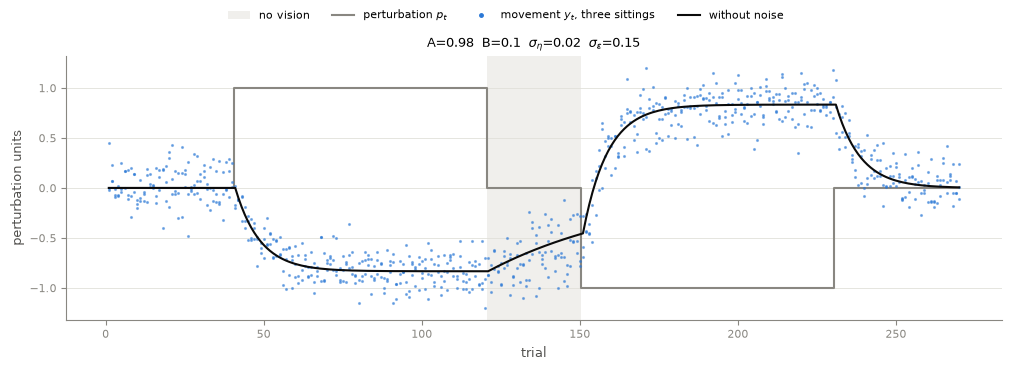

In [6]:
# [example-sittings] Three simulated sittings and the noise-free curve
A, B, sigma_eta, sigma_epsilon = theta_example
y_noisy = simulate_sitting(rng_example, theta_example, schedule, size=(3,))[0]["y"]
y_clean = simulate_sitting(rng_example, (A, B, tiny, tiny), schedule)[0]["y"]

fig, ax = plt.subplots(figsize=(10, 3.6))
for start, stop in zip(*np.nonzero(np.diff(np.r_[1, v, 1]) != 0)[0].reshape(-1, 2).T):
    ax.axvspan(start + 0.5, stop + 0.5, color=shade, lw=0, label="no vision")
ax.step(trial, p, where="mid", color=muted, lw=1.5, label="perturbation $p_t$")
ax.plot(trial, y_noisy.T, ".", color=blue, ms=2.5, alpha=0.5)
ax.plot([], [], ".", color=blue, ms=5, label="movement $y_t$, three sittings")
ax.plot(trial, y_clean, color="#0b0b0b", lw=1.5, label="without noise")
ax.set_xlabel("trial")
ax.set_ylabel("perturbation units")
ax.set_title("A={}  B={}  $\\sigma_\\eta$={}  $\\sigma_\\varepsilon$={}".format(*theta_example))
ax.grid(axis="y", color=grid, lw=0.6)
fig.legend(loc="outside upper center", frameon=False, fontsize=8, ncols=4)
plt.show()

## [check-1] Check 1: the noise-free learning curve

Without noise, and with a constant perturbation $p$ and vision, the model has a fixed
point $y^* = -Bp / (1 - A + B)$, and the movement approaches it geometrically:
$y_{t+1} - y^* = (A - B)(y_t - y^*)$. Without vision the movement only decays:
$y_{t+1} = A\, y_t$. These closed forms are computed Block by Block, starting each Block
where the previous one ended, and compared with the simulator run with negligible noise.

In [7]:
# [check-noise-free] Closed-form curve, block by block, against the noise-free simulation
closed_form = []
y_start = 0.0  # x_1 = 0 without noise
for trial_type, n in example_blocks:
    p_block, v_block = TRIAL_TYPES[trial_type]["p"], TRIAL_TYPES[trial_type]["v"]
    k = np.arange(n + 1)  # n trials of the block, plus the first trial of the next
    if v_block:
        y_star = -B * p_block / (1 - A + B)
        curve = y_star + (y_start - y_star) * (A - B) ** k
    else:
        curve = y_start * A**k
    closed_form.append(curve[:-1])
    y_start = curve[-1]
closed_form = np.concatenate(closed_form)

max_abs_diff = np.abs(closed_form - y_clean).max()
assert max_abs_diff < 1e-9
print(f"largest difference between closed form and simulation: {max_abs_diff:.1e}")

largest difference between closed form and simulation: 6.3e-12


## [check-2] Check 2: steady-state variability

Under a constant perturbation the movements settle into a stationary fluctuation around
the fixed point. Its size and its correlation from one Trial to the next follow from the
model. With vision, writing $V_x = (\sigma_\eta^2 + B^2\sigma_\varepsilon^2)/(1-(A-B)^2)$
for the variance of the plan:

$$
\sigma_y^2 = \sigma_\varepsilon^2 + V_x, \qquad
R(1) = \frac{(A - B)\, V_x - B\, \sigma_\varepsilon^2}{\sigma_y^2}
$$

Without vision:

$$
\sigma_y^2 = \sigma_\varepsilon^2 + \frac{\sigma_\eta^2}{1 - A^2}, \qquad
R(1) = \frac{A\, \sigma_\eta^2 / (1 - A^2)}{\sigma_y^2}
$$

These are equations 9, 11 and 12 of van der Vliet et al. (2018) with the geometric sums
added up. For $R(1)$ with vision, the paper's equation 10 is printed differently:
$+B\sigma_\varepsilon^2$ in the numerator, and $A^k(A-B)^k$ in place of $(A-B)^{2k}$ in
the denominator. Both versions are computed below, as `R1 formula` (derived above) and
`R1 eq. 10 as printed`.

For each parameter set, `n_sittings` Sittings are simulated under $p = 0$, first with
vision and then without. The first `t_burn` Trials are discarded; the standard deviation
and the lag-1 correlation are computed from the rest, pooled over Sittings. Standard
errors come from the spread between `n_batches` groups of Sittings.

In [8]:
# [check-stationary] Simulated steady-state statistics against the formulas
rows = []
for theta in stationary_thetas:
    A_, B_, s_eta, s_eps = theta
    for vision in (1, 0):
        T = t_burn + t_keep
        schedule = {"p": np.zeros(T), "v": np.full(T, vision)}
        y = simulate_sitting(rng_stationary, theta, schedule, size=(n_sittings,))[0]["y"]
        batches = y[:, t_burn:].reshape(n_batches, -1, t_keep)
        sd = batches.std(axis=(1, 2))
        r1 = np.array([np.corrcoef(b[:, :-1].ravel(), b[:, 1:].ravel())[0, 1] for b in batches])

        if vision:
            var_x = (s_eta**2 + B_**2 * s_eps**2) / (1 - (A_ - B_) ** 2)
            var_y = s_eps**2 + var_x
            r1_formula = ((A_ - B_) * var_x - B_ * s_eps**2) / var_y
            r1_printed = ((A_ - B_) * var_x + B_ * s_eps**2) / (
                s_eps**2 + (s_eta**2 + B_**2 * s_eps**2) / (1 - A_ * (A_ - B_))
            )
        else:
            var_y = s_eps**2 + s_eta**2 / (1 - A_**2)
            r1_formula = A_ * s_eta**2 / (1 - A_**2) / var_y
            r1_printed = np.nan  # equation 12 is the formula itself

        se_sd, se_r1 = sd.std(ddof=1) / np.sqrt(n_batches), r1.std(ddof=1) / np.sqrt(n_batches)
        rows.append({
            "theta (A, B, s_eta, s_eps)": theta,
            "vision": bool(vision),
            "sd simulated": sd.mean(),
            "sd formula": np.sqrt(var_y),
            "sd z": (sd.mean() - np.sqrt(var_y)) / se_sd,
            "R1 simulated": r1.mean(),
            "R1 formula": r1_formula,
            "R1 z": (r1.mean() - r1_formula) / se_r1,
            "R1 eq. 10 as printed": r1_printed,
        })
check_stationary = pd.DataFrame(rows)
check_stationary.round(4)

,"theta (A, B, s_eta, s_eps)",vision,sd simulated,sd formula,sd z,R1 simulated,R1 formula,R1 z,R1 eq. 10 as printed
0,"(0.98, 0.2, 0.02, 0.2)",True,0.2125,0.2124,0.8454,-0.0881,-0.0890,1.0368,0.2471
1,"(0.98, 0.2, 0.02, 0.2)",False,0.2238,0.2238,0.0628,0.1976,0.1976,0.0076,NaN
2,"(0.98, 0.05, 0.03, 0.1)",True,0.1297,0.1298,-0.8940,0.3477,0.3483,-0.6510,0.3360
3,"(0.98, 0.05, 0.03, 0.1)",False,0.1807,0.1809,-0.3280,0.6798,0.6806,-0.3947,NaN
4,"(0.95, 0.4, 0.05, 0.15)",True,0.1769,0.1768,1.5662,-0.1349,-0.1341,-1.2898,0.3915
5,"(0.95, 0.4, 0.05, 0.15)",False,0.2196,0.2194,0.4302,0.5073,0.5060,0.8164,NaN
6,"(0.995, 0.1, 0.01, 0.2)",True,0.2063,0.2062,0.9620,-0.0423,-0.0412,-1.4622,0.1402
7,"(0.995, 0.1, 0.01, 0.2)",False,0.2235,0.2237,-0.6498,0.1981,0.1994,-0.7440,NaN


## [results] What this shows

1. **Noise-free learning curve: pass.** The simulator and the closed form differ by at most
   $6 \times 10^{-12}$ over the example schedule, through all four kinds of block
   (`[check-noise-free]`).
2. **Steady-state variability: pass.** For all four parameter sets, with and without
   vision, the simulated standard deviation and lag-1 correlation agree with the formulas
   within Monte Carlo error: every z-score is below 1.6 in size (`[check-stationary]`).

**Equation 10 of the paper.** As printed it does not match the simulation: it gives
0.14 to 0.39 where the simulation gives $-0.13$ to $-0.04$ for three of the four parameter
sets. The derived version matches. Either equation 10 has two misprints or I have
misread it; the paper's figures may well have been drawn with a correct version, which
this notebook does not check.

**What the derived formula says.** With vision, successive movements can be *negatively*
correlated: the $-B\,\sigma_\varepsilon^2$ term is the learner correcting, on the next
trial, the execution noise of this one. That happens when $B$ is large relative to the
ratio of planning to execution noise. Without vision, successive movements are always
positively correlated, because the planning noise accumulates uncorrected. This
difference is what lets no-vision blocks separate the two noises.